# 01 · Dataset analysis

Read-only analysis of the plant disease dataset at `Dataset/raw/`.
Nothing in the dataset is modified.

The per-image inventory (format, size, MD5, perceptual hash, decode errors) is
produced by `scripts/inspect_dataset.py`, which fully decodes every image. It is
regenerated here only if it is missing, because the full scan takes several minutes.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

# Chart styling: light surface, recessive axes, fixed categorical order.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]   # train, val/valid, test
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#b5b4ad", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": "#0b0b0b",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "font.size": 9, "axes.titlesize": 11, "axes.titleweight": "bold",
})

from src.preprocessing import config

if not config.INVENTORY_CSV.exists():
    import subprocess
    subprocess.run([sys.executable, str(ROOT / "scripts" / "inspect_dataset.py")], check=True)

inv = pd.read_csv(config.INVENTORY_CSV)
parts = inv["path"].str.split("/", expand=True)
inv["split"] = parts[0]
inv["label"] = parts[1].where(parts[2].notna())
inv["crop"] = inv["label"].str.split("___").str[0]
inv["condition"] = inv["label"].str.split("___").str[1]
print(f"{len(inv):,} files inventoried under {config.DATASET_DIR}")

52,747 files inventoried under C:\Users\H P\Desktop\Study\7 - Sem\Project\new smart crop care\Dataset\raw


## 1 · Structure and split sizes

In [2]:
overview = inv.groupby("split").agg(images=("path", "size"), classes=("label", "nunique"))
overview.loc["total"] = [overview["images"].sum(), inv["label"].nunique()]
overview

,images,classes
split,,
test,33,0
train,35145,38
valid,17569,38
total,52747,38


* `train/` and `valid/` each contain one folder per class (38 folders, identical names).
* `test/` is a flat folder of 33 images; the label is only encoded in the file name.

## 2 · Images per class

In [3]:
per_class = inv[inv["label"].notna()].pivot_table(
    index="label", columns="split", values="path", aggfunc="count", fill_value=0)
per_class["total"] = per_class.sum(axis=1)
per_class["valid/train"] = (per_class["valid"] / per_class["train"]).round(3)
per_class

split,train,valid,total,valid/train
label,,,,
Apple___Apple_scab,1008,504,1512,0.500
Apple___Black_rot,994,497,1491,0.500
Apple___Cedar_apple_rust,880,440,1320,0.500
Apple___healthy,1004,502,1506,0.500
Blueberry___healthy,908,454,1362,0.500
Cherry_(including_sour)___Powdery_mildew,842,421,1263,0.500
Cherry_(including_sour)___healthy,913,456,1369,0.499
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,817,407,1224,0.498
Corn_(maize)___Common_rust_,954,477,1431,0.500


In [4]:
stats = per_class["train"].describe()[["min", "max", "mean", "std"]].round(1)
print("Train images per class:", stats.to_dict())
print(f"Imbalance ratio (max/min): {per_class['train'].max() / per_class['train'].min():.2f}")

Train images per class: {'min': 817.0, 'max': 1011.0, 'mean': 924.9, 'std': 53.1}
Imbalance ratio (max/min): 1.24


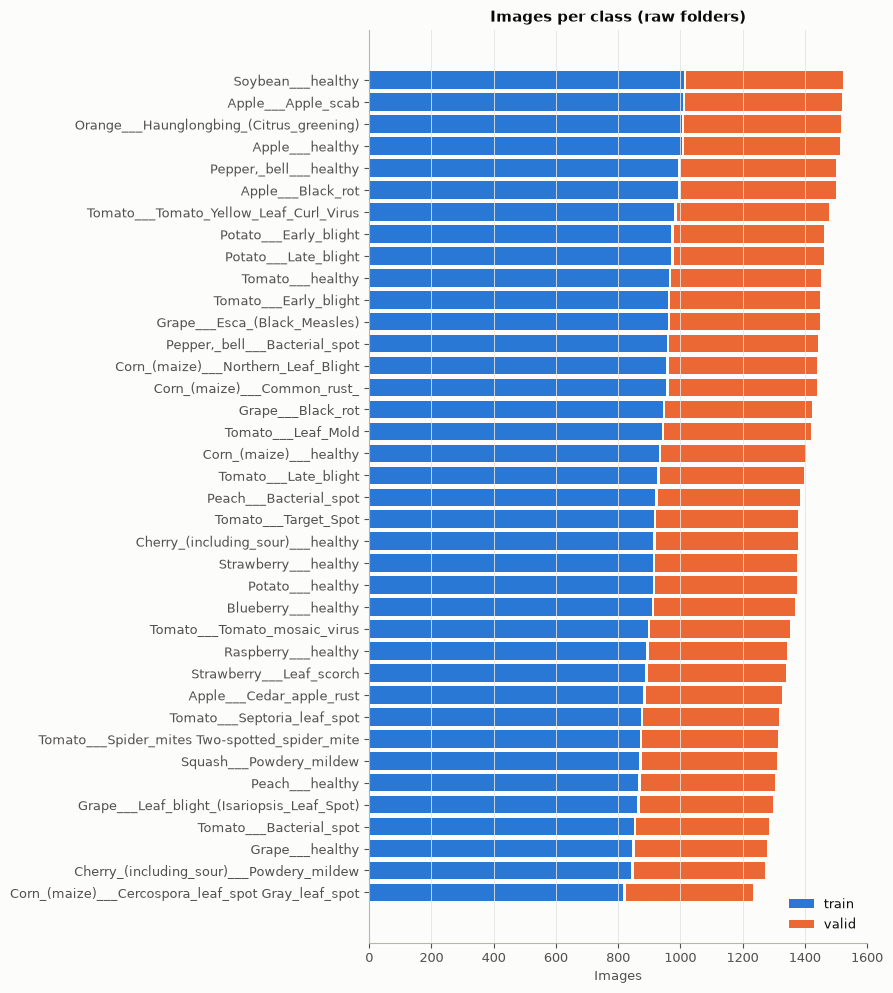

In [5]:
order = per_class.sort_values("total").index
fig, ax = plt.subplots(figsize=(9, 10))
y = np.arange(len(order))
ax.barh(y, per_class.loc[order, "train"], color=SERIES[0], height=0.8, label="train")
ax.barh(y, per_class.loc[order, "valid"], left=per_class.loc[order, "train"] + 8,
        color=SERIES[1], height=0.8, label="valid")
ax.set_yticks(y, order)
ax.set_xlabel("Images")
ax.set_title("Images per class (raw folders)")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "01_images_per_class.png", dpi=120)
plt.show()

## 3 · Crops and conditions

In [6]:
crops = (inv[inv["label"].notna()].groupby("crop")
         .agg(classes=("label", "nunique"), images=("path", "size"),
              healthy_class=("condition", lambda s: (s == "healthy").any()))
         .sort_values("images", ascending=False))
print(f"{len(crops)} crops, {inv['label'].nunique()} classes "
      f"({(inv.drop_duplicates('label')['condition'] == 'healthy').sum()} healthy, "
      f"{(inv.drop_duplicates('label')['condition'] != 'healthy').sum() - 1} disease)")
crops

14 crops, 38 classes (12 healthy, 26 disease)


,classes,images,healthy_class
crop,,,
Tomato,10,13757,True
Apple,4,5829,True
Corn_(maize),4,5481,True
Grape,4,5416,True
Potato,3,4278,True
"Pepper,_bell",2,2925,True
Strawberry,2,2699,True
Peach,2,2674,True
Cherry_(including_sour),2,2632,True


## 4 · Formats, colour modes, dimensions, file sizes

In [7]:
for col in ["ext", "format", "mode"]:
    print(col, inv[col].value_counts(dropna=False).to_dict())
inv["dims"] = inv["width"].astype("Int64").astype(str) + "x" + inv["height"].astype("Int64").astype(str)
print("dimensions", inv["dims"].value_counts().to_dict())
print("file size (KB):", (inv["bytes"] / 1024).describe()[["min", "50%", "max"]].round(1).to_dict())

ext {'.JPG': 50934, '.jpg': 1813}
format {'JPEG': 52747}
mode {'RGB': 52747}
dimensions {'256x256': 52747}
file size (KB): {'min': 3.3, '50%': 16.3, 'max': 30.0}


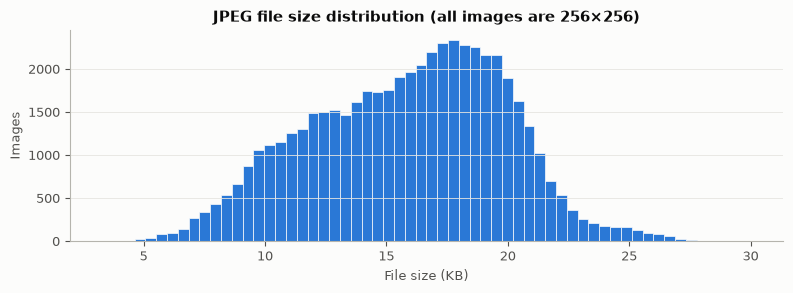

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(inv["bytes"] / 1024, bins=60, color=SERIES[0], edgecolor="#fcfcfb", linewidth=0.5)
ax.set_xlabel("File size (KB)")
ax.set_ylabel("Images")
ax.set_title("JPEG file size distribution (all images are 256×256)")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 5 · Integrity

In [9]:
integrity = {
    "decode errors (corrupted)": int(inv["error"].notna().sum()),
    "zero-byte files": int((inv["bytes"] == 0).sum()),
    "non-JPEG content": int((inv["format"] != "JPEG").sum()),
    "non-RGB images": int((inv["mode"] != "RGB").sum()),
    "not 256x256": int((inv["dims"] != "256x256").sum()),
}
integrity

{'decode errors (corrupted)': 0,
 'zero-byte files': 0,
 'non-JPEG content': 0,
 'non-RGB images': 0,
 'not 256x256': 0}

## 6 · Sample image per class

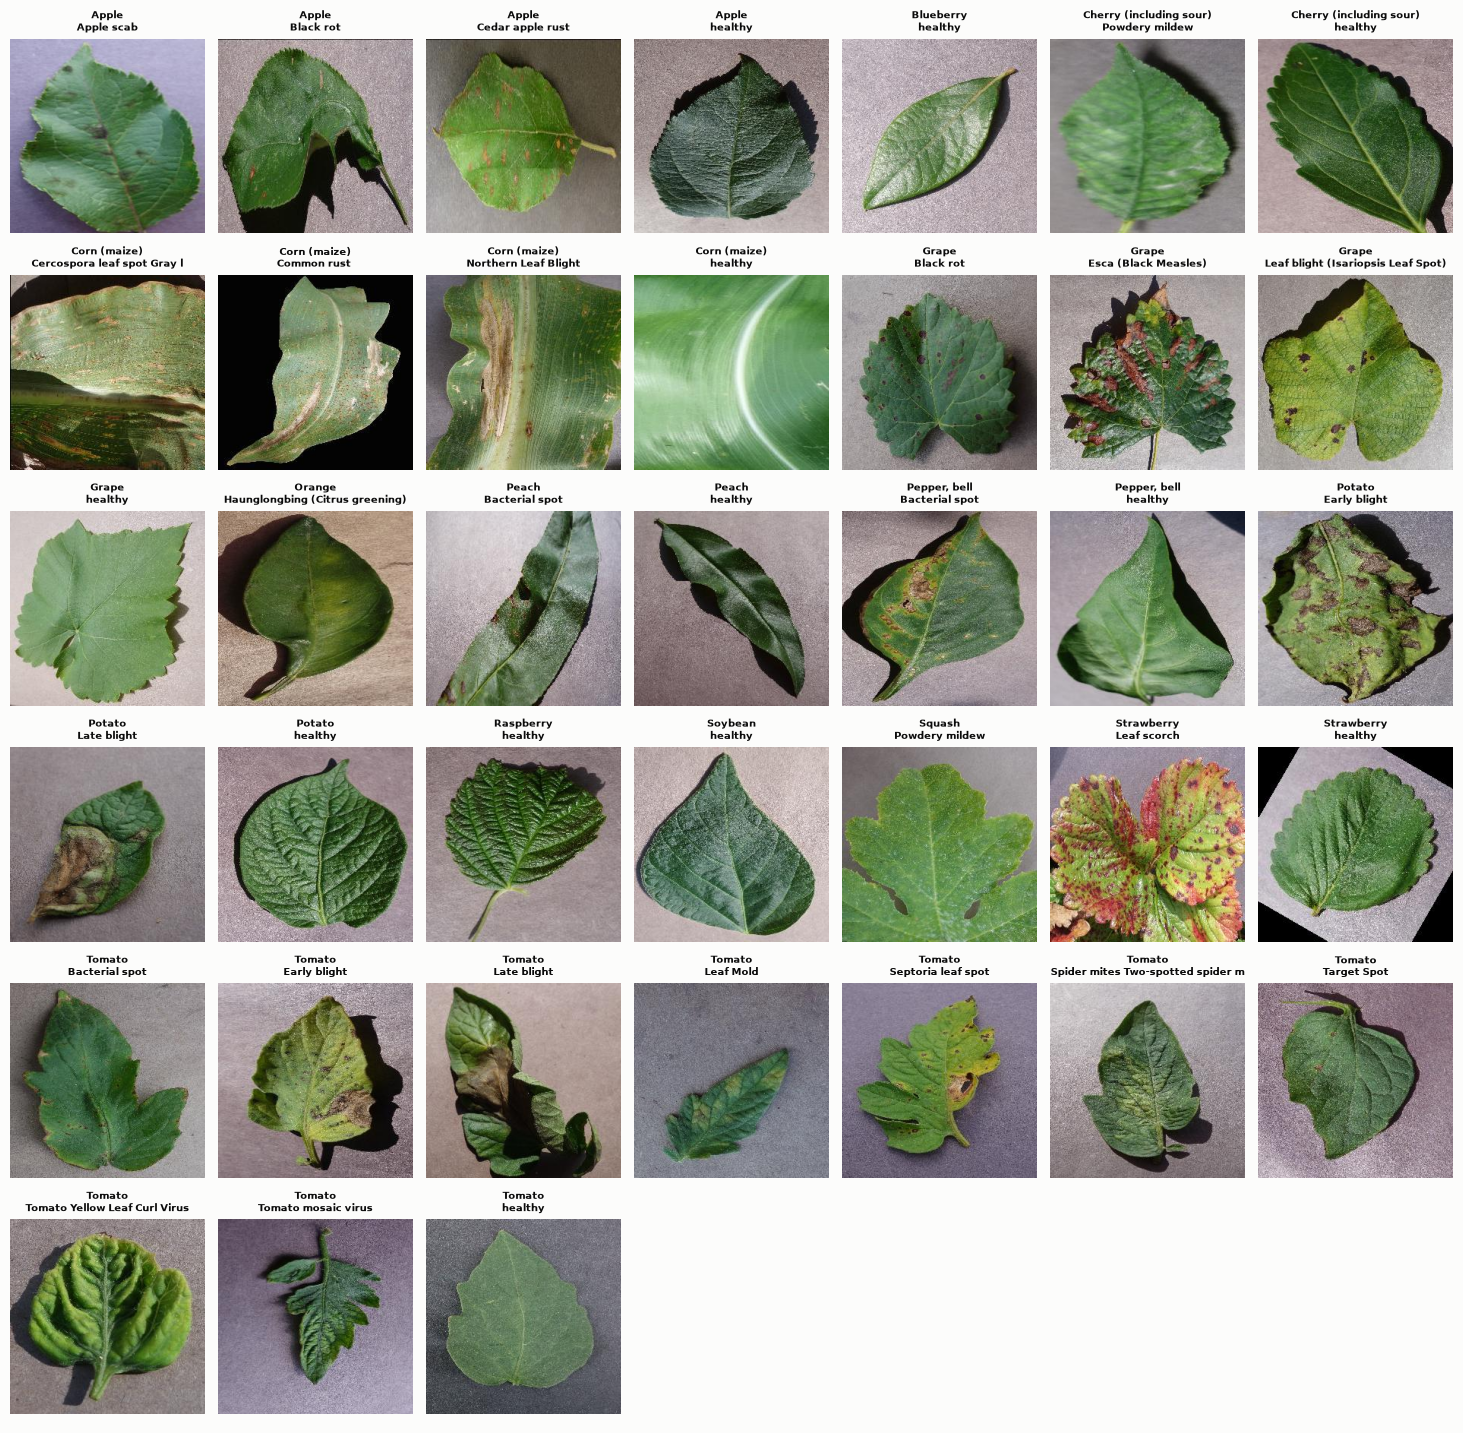

In [10]:
from PIL import Image

samples = inv[inv["split"] == "train"].groupby("label").head(1).sort_values("label")
cols = 7
rows = int(np.ceil(len(samples) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.1, rows * 2.4))
for ax in axes.flat:
    ax.axis("off")
for ax, (_, r) in zip(axes.flat, samples.iterrows()):
    ax.imshow(Image.open(config.DATASET_DIR / r["path"]))
    ax.set_title(r["label"].replace("___", "\n").replace("_", " ")[:40], fontsize=7)
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "01_sample_per_class.png", dpi=100)
plt.show()

## 7 · Duplicates

In [11]:
dupes = inv[inv.duplicated("md5", keep=False)].sort_values("md5")
groups = dupes.groupby("md5")["split"].agg(lambda s: " + ".join(sorted(set(s))))
print("Exact-duplicate groups by splits involved:", groups.value_counts().to_dict())

test = inv[inv["split"] == "test"]
twin = inv[inv["split"] != "test"].drop_duplicates("md5").set_index("md5")["path"]
test_twins = test.assign(identical_to=test["md5"].map(twin))[["path", "identical_to"]]
print(f"Supplied test images with a byte-identical copy in valid/: "
      f"{test_twins['identical_to'].str.startswith('valid/').sum()} / {len(test)}")
test_twins.head(10)

Exact-duplicate groups by splits involved: {'test + valid': 33, 'valid': 2, 'train': 2, 'train + valid': 1}
Supplied test images with a byte-identical copy in valid/: 33 / 33


,path,identical_to
0,test/AppleCedarRust1.JPG,valid/Apple___Cedar_apple_rust/0cd24b0c-0a9d-4...
1,test/AppleCedarRust2.JPG,valid/Apple___Cedar_apple_rust/0ce943e7-3fed-4...
2,test/AppleCedarRust3.JPG,valid/Apple___Cedar_apple_rust/0fbdccdc-fb96-4...
3,test/AppleCedarRust4.JPG,valid/Apple___Cedar_apple_rust/1e099d8e-b40c-4...
4,test/AppleScab1.JPG,valid/Apple___Apple_scab/0a5e9323-dbad-432d-ac...
5,test/AppleScab2.JPG,valid/Apple___Apple_scab/2a800c84-902e-4aa8-af...
6,test/AppleScab3.JPG,valid/Apple___Apple_scab/2f668a95-80ab-40ac-98...
7,test/CornCommonRust1.JPG,valid/Corn_(maize)___Common_rust_/RS_Rust 1564...
8,test/CornCommonRust2.JPG,valid/Corn_(maize)___Common_rust_/RS_Rust 1585...
9,test/CornCommonRust3.JPG,valid/Corn_(maize)___Common_rust_/RS_Rust 1663...


In [12]:
near = inv[inv["split"] != "test"]
near = near[near.duplicated("phash", keep=False) & ~near.duplicated("md5", keep=False)]
near_groups = near.groupby("phash").agg(n=("path", "size"), labels=("label", "nunique"),
                                        splits=("split", lambda s: " + ".join(sorted(set(s)))))
print(f"Near-duplicate groups (same perceptual hash, different bytes): {len(near_groups)}")
print("Groups spanning more than one class:", int((near_groups['labels'] > 1).sum()))
near_groups["splits"].value_counts()

Near-duplicate groups (same perceptual hash, different bytes): 41
Groups spanning more than one class: 0


splits
train + valid    19
train            17
valid             5
Name: count, dtype: int64

## 8 · Leakage between train/ and valid/

File names follow `<uuid>___<source leaf id>[_<augmentation>].JPG`. The dataset was
augmented offline (flips, rotations, colour changes) **before** it was divided into
train/ and valid/, so augmented copies of one physical leaf are spread across both.

In [13]:
from src.preprocessing.splits import parse_name, AUG_SUFFIX

lab = inv[inv["label"].notna()].copy()
lab["filename"] = lab["path"].str.rsplit("/", n=1).str[-1]
lab["leaf_key"] = lab["filename"].map(lambda f: parse_name(f)[1])
lab["aug"] = lab["filename"].str.rsplit(".", n=1).str[0].str.extract(AUG_SUFFIX, expand=False)

print("Augmentation suffixes:", lab["aug"].value_counts().to_dict())
print(f"Augmented files: {lab['aug'].notna().sum():,} of {len(lab):,}")

leaf_splits = lab.groupby(["label", "leaf_key"])["split"].nunique()
print(f"Distinct source leaves: {len(leaf_splits):,}; "
      f"present in BOTH train and valid: {(leaf_splits > 1).sum():,} "
      f"({(leaf_splits > 1).mean():.1%})")

Augmentation suffixes: {'flipLR': 5245, '180deg': 5188, 'flipTB': 4411, 'new30degFlipLR': 2985, '90deg': 2525, '270deg': 2487, 'newPixel25': 1452, 'new30degFlipTB': 260, 'newGRR': 246, 'new200degFlipTB': 97, 'new90degFlipLR': 97, 'new200degFlipLR': 93, 'newGGR': 83, 'new90degFlipTB': 80}
Augmented files: 25,249 of 52,714
Distinct source leaves: 33,558; present in BOTH train and valid: 6,391 (19.0%)


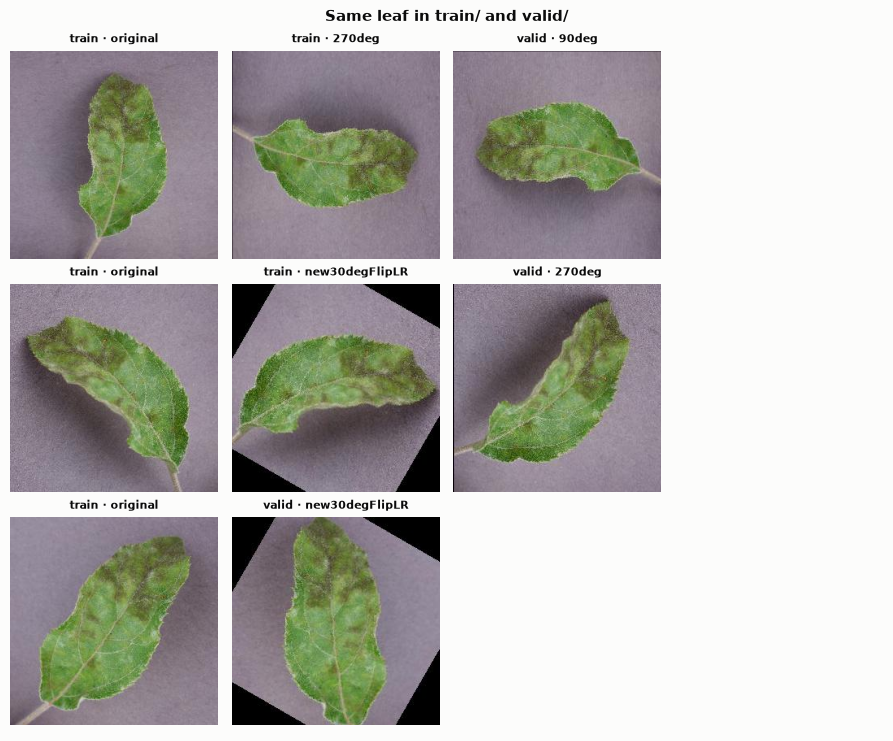

In [14]:
shared = leaf_splits[leaf_splits > 1].index[:3]
fig, axes = plt.subplots(len(shared), 4, figsize=(9, 2.5 * len(shared)))
for row, (label, key) in zip(axes, shared):
    files = lab[(lab["label"] == label) & (lab["leaf_key"] == key)].sort_values("split").head(4)
    for ax in row:
        ax.axis("off")
    for ax, (_, r) in zip(row, files.iterrows()):
        ax.imshow(Image.open(config.DATASET_DIR / r["path"]))
        ax.set_title(f"{r['split']} · {r['aug'] if isinstance(r['aug'], str) else 'original'}",
                     fontsize=8)
fig.suptitle("Same leaf in train/ and valid/", fontweight="bold")
fig.tight_layout()
plt.show()

## Conclusions

* **38 classes, 14 crops, 52,747 images**, all readable 256×256 RGB JPEGs, well
  balanced (train imbalance ratio ≈ 1.24).
* **The supplied `test/` folder is not independent**: all 33 images are byte copies of
  `valid/` files and cover only 8 classes.
* **`train/` and `valid/` leak into each other**: augmented copies of the same leaf
  are on both sides, so validation accuracy on the original split would be inflated.
* A handful of exact duplicates exist inside the labelled data.

➡ Preprocessing (notebook 02) pools train/ + valid/, groups images by physical leaf
and re-splits whole groups into train/val/test.